In [189]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [190]:
df = pd.read_csv("WorldEnergy_.csv")

df.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [191]:
data = df[['country', 'year', 'gdp', 'nuclear_share_elec', 'greenhouse_gas_emissions']].copy()

In [192]:
data = data.dropna(subset=[
    'country', 
    'gdp', 
    'nuclear_share_elec', 
    'greenhouse_gas_emissions'
])

In [193]:
exclude_keywords = [
    'World', 'Asia', 'Africa', 'Europe', 'America',
    'income', 'OECD', 'G20', 'G7', 'EU', 'Ember'
]

data = data[
    ~data['country'].str.contains('|'.join(exclude_keywords), case=False, na=False)
].copy()

print("Countries remaining:", data['country'].nunique())

Countries remaining: 163


In [205]:
data = data.rename(columns={'greenhouse_gas_emissions': 'ghg'})

In [206]:
data = data[
    (data['gdp'] > 0) &
    (data['ghg'] > 0) &
    (data['nuclear_share_elec'] > 0)
].copy()
print("Rows after filtering:", len(data))

Rows after filtering: 694


In [207]:
data['log_ghg'] = np.log10(data['ghg'])
data['log_gdp'] = np.log10(data['gdp'])

In [208]:
data['gdp_group'] = pd.qcut(
    data['gdp'],
    q=3,
    labels=['Low GDP', 'Middle GDP', 'High GDP']
)

In [209]:
data['nuclear_group'] = pd.qcut(
    data['nuclear_share_elec'],
    q=3,
    labels=['Low Nuclear', 'Medium Nuclear', 'High Nuclear']
)

In [210]:
print(data.groupby(['gdp_group', 'nuclear_group']).size())

gdp_group   nuclear_group 
Low GDP     Low Nuclear        11
            Medium Nuclear     66
            High Nuclear      154
Middle GDP  Low Nuclear       115
            Medium Nuclear     62
            High Nuclear       55
High GDP    Low Nuclear       105
            Medium Nuclear    103
            High Nuclear       23
dtype: int64


C:\Users\Chee Zing\AppData\Local\Temp\ipykernel_19612\1416240683.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data.groupby(['gdp_group', 'nuclear_group']).size())


In [211]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 694 entries, 1126 to 21818
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   country             694 non-null    object  
 1   year                694 non-null    int64   
 2   gdp                 694 non-null    float64 
 3   nuclear_share_elec  694 non-null    float64 
 4   ghg                 694 non-null    float64 
 5   log_ghg             694 non-null    float64 
 6   log_gdp             694 non-null    float64 
 7   gdp_group           694 non-null    category
 8   nuclear_group       694 non-null    category
dtypes: category(2), float64(5), int64(1), object(1)
memory usage: 45.0+ KB
None


In [212]:
print(data[['gdp', 'nuclear_share_elec', 'ghg']].describe())

                gdp  nuclear_share_elec          ghg
count  6.940000e+02          694.000000   694.000000
mean   2.257191e+12           25.664487   297.344092
std    4.010486e+12           19.705998   715.385790
min    1.524483e+10            0.047000     0.730000
25%    2.836155e+11            6.675750    16.635000
50%    8.235258e+11           20.822500    53.805000
75%    2.296028e+12           37.972500   184.830000
max    2.696602e+13           82.253000  5191.540000


In [213]:
print("GDP group distribution:")
print(data['gdp_group'].value_counts())

print("\nNuclear group distribution:")
print(data['nuclear_group'].value_counts())

GDP group distribution:
gdp_group
Middle GDP    232
Low GDP       231
High GDP      231
Name: count, dtype: int64

Nuclear group distribution:
nuclear_group
High Nuclear      232
Low Nuclear       231
Medium Nuclear    231
Name: count, dtype: int64


In [214]:
print("\nMean GHG by GDP group:")
print(data.groupby('gdp_group')['log_ghg'].mean())

print("\nMean GHG by Nuclear group:")
print(data.groupby('nuclear_group')['log_ghg'].mean())

print("\nMean GHG by both:")
print(data.groupby(['gdp_group', 'nuclear_group'])['log_ghg'].mean())


Mean GHG by GDP group:
gdp_group
Low GDP       1.009856
Middle GDP    1.738103
High GDP      2.534279
Name: log_ghg, dtype: float64

Mean GHG by Nuclear group:
nuclear_group
Low Nuclear       2.188681
Medium Nuclear    2.041571
High Nuclear      1.054943
Name: log_ghg, dtype: float64

Mean GHG by both:
gdp_group   nuclear_group 
Low GDP     Low Nuclear       1.411815
            Medium Nuclear    1.190855
            High Nuclear      0.903573
Middle GDP  Low Nuclear       1.887074
            Medium Nuclear    1.893305
            High Nuclear      1.251662
High GDP    Low Nuclear       2.600397
            Medium Nuclear    2.675936
            High Nuclear      1.598052
Name: log_ghg, dtype: float64


C:\Users\Chee Zing\AppData\Local\Temp\ipykernel_19612\3842249110.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data.groupby('gdp_group')['log_ghg'].mean())
C:\Users\Chee Zing\AppData\Local\Temp\ipykernel_19612\3842249110.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data.groupby('nuclear_group')['log_ghg'].mean())
C:\Users\Chee Zing\AppData\Local\Temp\ipykernel_19612\3842249110.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future def

In [215]:
corr = data[['log_gdp', 'nuclear_share_elec', 'log_ghg']].corr()
print(corr)

                     log_gdp  nuclear_share_elec   log_ghg
log_gdp             1.000000           -0.492595  0.892535
nuclear_share_elec -0.492595            1.000000 -0.570577
log_ghg             0.892535           -0.570577  1.000000


In [216]:
print(data.isnull().sum())

country               0
year                  0
gdp                   0
nuclear_share_elec    0
ghg                   0
log_ghg               0
log_gdp               0
gdp_group             0
nuclear_group         0
dtype: int64


In [217]:
print(data.isnull().sum())

country               0
year                  0
gdp                   0
nuclear_share_elec    0
ghg                   0
log_ghg               0
log_gdp               0
gdp_group             0
nuclear_group         0
dtype: int64


In [218]:
Q1 = data['log_ghg'].quantile(0.25)
Q3 = data['log_ghg'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[
    (data['log_ghg'] < lower) |
    (data['log_ghg'] > upper)
]

print("Outliers count:", len(outliers))

Outliers count: 0


In [219]:
mean_gdp_actual = data.groupby('gdp_group')['gdp'].mean()
print(mean_gdp_actual)


gdp_group
Low GDP       1.863169e+11
Middle GDP    9.250289e+11
High GDP      5.665994e+12
Name: gdp, dtype: float64


C:\Users\Chee Zing\AppData\Local\Temp\ipykernel_19612\3391637652.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_gdp_actual = data.groupby('gdp_group')['gdp'].mean()


In [220]:
mean_nuclear_actual = data.groupby('nuclear_group')['nuclear_share_elec'].mean()
print(mean_nuclear_actual)

nuclear_group
Low Nuclear        5.233346
Medium Nuclear    23.268463
High Nuclear      48.393259
Name: nuclear_share_elec, dtype: float64


C:\Users\Chee Zing\AppData\Local\Temp\ipykernel_19612\2870614767.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_nuclear_actual = data.groupby('nuclear_group')['nuclear_share_elec'].mean()


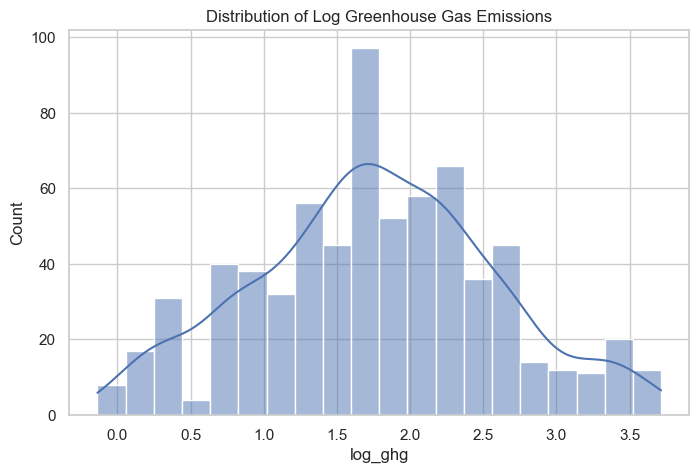

In [221]:
plt.figure(figsize=(8,5))
sns.histplot(data['log_ghg'], bins=20, kde=True)

plt.title("Distribution of Log Greenhouse Gas Emissions")
plt.show()

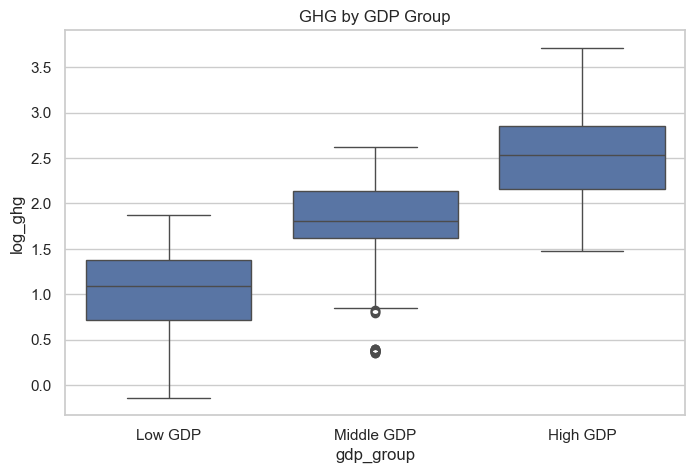

In [222]:
plt.figure(figsize=(8,5))
sns.boxplot(x='gdp_group', y='log_ghg', data=data)

plt.title("GHG by GDP Group")
plt.show()

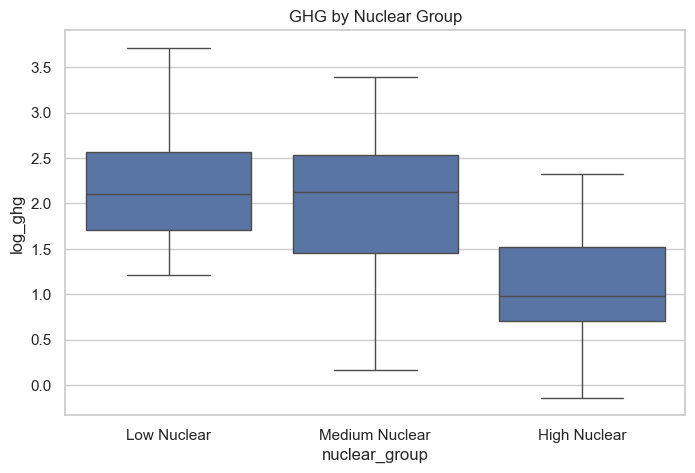

In [223]:
plt.figure(figsize=(8,5))
sns.boxplot(x='nuclear_group', y='log_ghg', data=data)

plt.title("GHG by Nuclear Group")
plt.show()

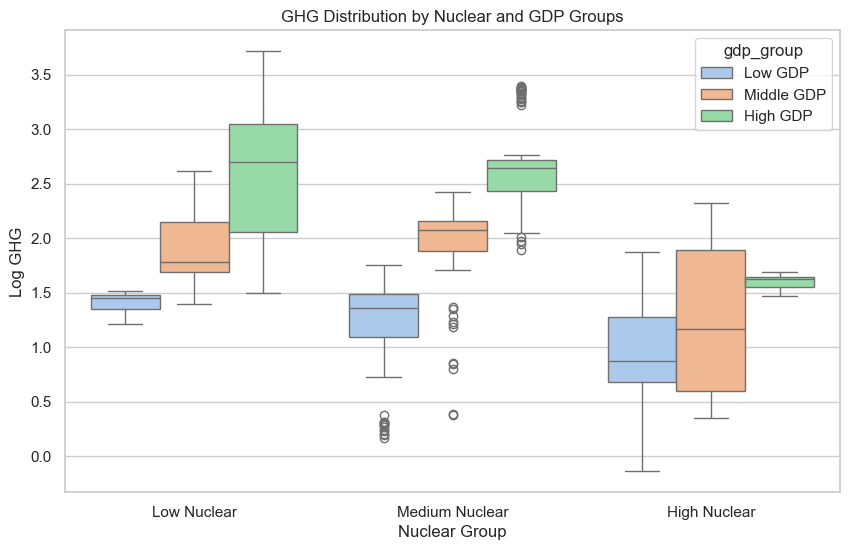

In [224]:
palette = ['#4C72B0', '#DD8452', '#55A868']
plt.figure(figsize=(10,6))

sns.boxplot(
    x='nuclear_group',
    y='log_ghg',
    hue='gdp_group',
    data=data,
    palette='pastel'
)

plt.title("GHG Distribution by Nuclear and GDP Groups")
plt.xlabel("Nuclear Group")
plt.ylabel("Log GHG")
plt.show()

C:\Users\Chee Zing\AppData\Local\Temp\ipykernel_19612\2437010207.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_gdp = data.groupby('gdp_group')['log_ghg'].mean().reset_index()


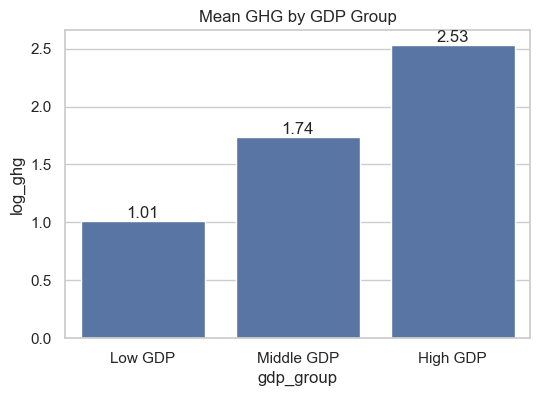

In [225]:
mean_gdp = data.groupby('gdp_group')['log_ghg'].mean().reset_index()

plt.figure(figsize=(6,4))
ax = sns.barplot(x='gdp_group', y='log_ghg', data=mean_gdp)

for c in ax.containers:
    ax.bar_label(c, fmt='%.2f')

plt.title("Mean GHG by GDP Group")
plt.show()

C:\Users\Chee Zing\AppData\Local\Temp\ipykernel_19612\568478793.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_nuclear = data.groupby('nuclear_group')['log_ghg'].mean().reset_index()


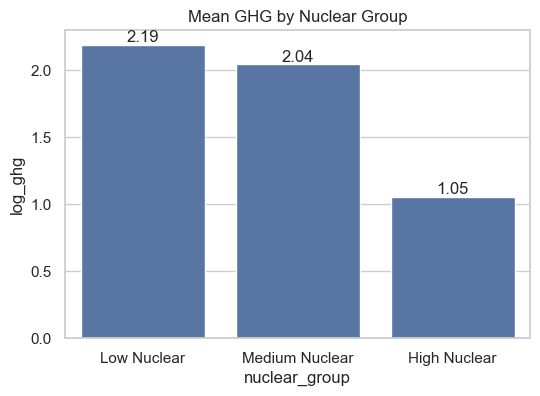

In [226]:
mean_nuclear = data.groupby('nuclear_group')['log_ghg'].mean().reset_index()

plt.figure(figsize=(6,4))
ax = sns.barplot(x='nuclear_group', y='log_ghg', data=mean_nuclear)

for c in ax.containers:
    ax.bar_label(c, fmt='%.2f')

plt.title("Mean GHG by Nuclear Group")
plt.show()

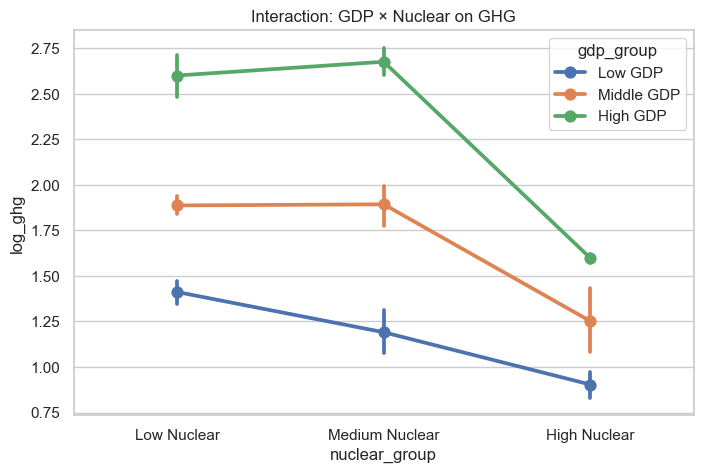

In [227]:
plt.figure(figsize=(8,5))

sns.pointplot(
    x='nuclear_group',
    y='log_ghg',
    hue='gdp_group',
    data=data
)

plt.title("Interaction: GDP × Nuclear on GHG")
plt.show()

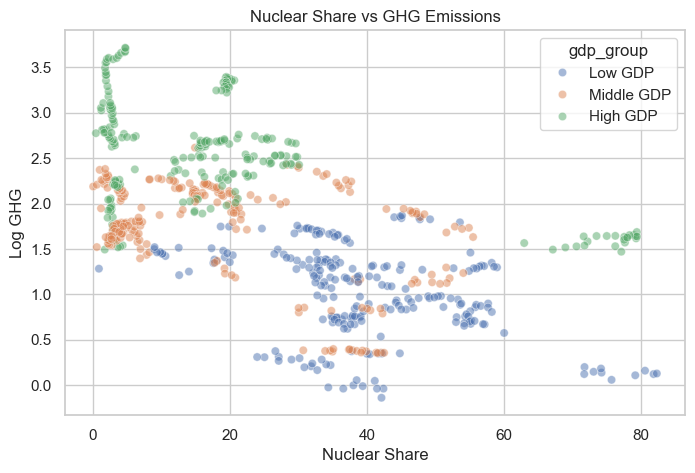

In [228]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='nuclear_share_elec',
    y='log_ghg',
    hue='gdp_group',
    data=data,
    alpha=0.5
)

plt.title("Nuclear Share vs GHG Emissions")
plt.xlabel("Nuclear Share")
plt.ylabel("Log GHG")
plt.show()

C:\Users\Chee Zing\AppData\Local\Temp\ipykernel_19612\982426351.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = data.pivot_table(


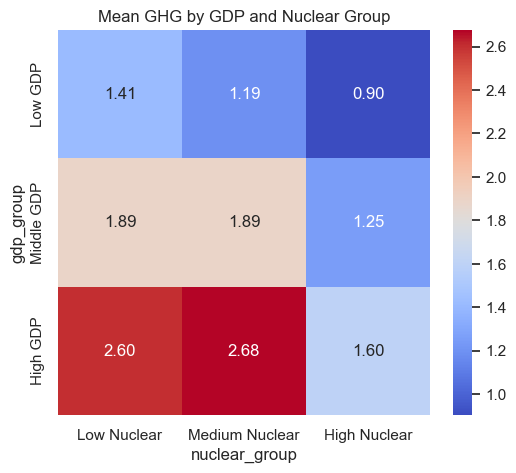

In [229]:
pivot = data.pivot_table(
    values='log_ghg',
    index='gdp_group',
    columns='nuclear_group',
    aggfunc='mean'
)

plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Mean GHG by GDP and Nuclear Group")
plt.show()

In [230]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

model_2way = ols(
    'log_ghg ~ C(gdp_group) * C(nuclear_group)',
    data=data
).fit()

anova_2way = sm.stats.anova_lm(model_2way, typ=2)
print(anova_2way)

                                   sum_sq     df           F        PR(>F)
C(gdp_group)                   129.240295    2.0  286.285511  4.306577e-91
C(nuclear_group)                36.747967    2.0   81.401939  1.917992e-32
C(gdp_group):C(nuclear_group)    8.676921    4.0    9.610303  1.451091e-07
Residual                       154.617678  685.0         NaN           NaN


In [231]:
from scipy import stats

residuals = model_2way.resid
shapiro_test = stats.shapiro(residuals)

print("Shapiro-Wilk Test:", shapiro_test)

Shapiro-Wilk Test: ShapiroResult(statistic=0.9864891971859391, pvalue=5.0435220143686835e-06)


In [232]:
groups = [group["log_ghg"].values for name, group in data.groupby(['gdp_group','nuclear_group'])]

levene_test = stats.levene(*groups)

print("Levene Test:", levene_test)

Levene Test: LeveneResult(statistic=14.653871702441133, pvalue=7.103162673256211e-20)


C:\Users\Chee Zing\AppData\Local\Temp\ipykernel_19612\3244460042.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group["log_ghg"].values for name, group in data.groupby(['gdp_group','nuclear_group'])]


In [233]:
eta_sq = anova_2way['sum_sq'] / sum(anova_2way['sum_sq'])
print(eta_sq)

C(gdp_group)                     0.392490
C(nuclear_group)                 0.111600
C(gdp_group):C(nuclear_group)    0.026351
Residual                         0.469559
Name: sum_sq, dtype: float64
